**0. Imports:**

In [1]:
import earthcarekit as eck
eck.set_config("/usr/people/raucher/Documents/Config_ECK/default_config.toml")
import xarray as xr
xr.set_options(display_expand_data_vars=True, display_max_rows=500, display_max_items=10000)
import re
import numpy as np
import pandas as pd
from IPython.display import display
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d
import sys
import shlex
import shutil
from datetime import date

Default config set at </usr/people/raucher/.config/earthcarekit/default_config.toml>


**0b. Remote ZIP Helpers**

In [2]:
# Import command runner from my_subprocess.py
MY_SUBPROCESS_FILE = Path("/usr/people/raucher/Documents/Coding1/Gerd-Jan/OneDrive_1_24-2-2026")
if str(MY_SUBPROCESS_FILE) not in sys.path:
    sys.path.insert(0, str(MY_SUBPROCESS_FILE))

from my_subprocess import run_shell_cmd_and_communicate, print_shell_output


def _to_date(v):
    if isinstance(v, datetime): return v.date()
    if isinstance(v, date):     return v
    if isinstance(v, str):      return datetime.strptime(v, "%Y-%m-%d").date()
    raise TypeError(f"Unsupported date type: {type(v)}")


def run_cmd_checked(cmd: str, verbose: bool = False):
    lines_out, lines_err, rc = run_shell_cmd_and_communicate(cmd, verbose=verbose)
    if rc != 0:
        print_shell_output(lines_out, lines_err, prefix="[shell] ")
        raise RuntimeError(f"Command failed (exit {rc}): {cmd}")
    return lines_out, lines_err


def discover_remote_zip_files(remote_product_root, start_date, end_date):
    root  = Path(remote_product_root)
    start = _to_date(start_date)
    end   = _to_date(end_date)
    if end < start:
        raise ValueError("end_date must be >= start_date")
    zips = []
    day  = start
    while day <= end:
        day_dir = root / day.strftime("%Y") / day.strftime("%m") / day.strftime("%d")
        if day_dir.exists():
            zips.extend(sorted(day_dir.glob("*.ZIP")))
            zips.extend(sorted(day_dir.glob("*.zip")))
        day += timedelta(days=1)
    return sorted(dict.fromkeys(zips))


def stage_zip_and_extract(src_zip: Path, local_stage_root: Path):
    local_stage_root.mkdir(parents=True, exist_ok=True)
    local_zip   = local_stage_root / src_zip.name
    extract_dir = local_stage_root / src_zip.stem
    if local_zip.exists():   local_zip.unlink()
    if extract_dir.exists(): shutil.rmtree(extract_dir)
    run_cmd_checked(f"cp {shlex.quote(str(src_zip))} {shlex.quote(str(local_zip))}")
    run_cmd_checked(f"unzip -oq {shlex.quote(str(local_zip))} -d {shlex.quote(str(extract_dir))}")
    h5_files = sorted(extract_dir.rglob("*.h5"))
    if not h5_files:
        raise FileNotFoundError(f"No .h5 after extracting: {src_zip}")
    return local_zip, extract_dir, h5_files


def cleanup_staged_data(local_zip: Path | None, extract_dir: Path | None):
    if extract_dir is not None and extract_dir.exists(): shutil.rmtree(extract_dir)
    if local_zip   is not None and local_zip.exists():   local_zip.unlink()

**1. Config**

In [3]:
# Input data
REMOTE_PRODUCT_ROOT = Path("/net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/AC__TC__2B")

# Local staging folder for temporary ZIP/extracted data (safe to clean up)
LOCAL_STAGE_ROOT = Path("/usr/people/raucher/Documents/Coding1/KNMI/KNMI/temp_ZIPs_2B")
LOCAL_STAGE_ROOT.mkdir(parents=True, exist_ok=True)

START_DATE = "2025-01=== SHAPE CHECKS ===
cls_raw dtype:  int8   shape: (4945, 242)
cls_f   dtype:  float64
h       dtype:  float32          shape: (4945, 242)

=== HEIGHT RANGE ===
h min=-489.2  max=39849.7  (should be ~0..24100 m)
target_h min=0.0  max=20000.0
h range overlaps target_h: True

=== RAW CLASS VALUES vs TARGET_CLASSES ===
Unique codes in file (raw): [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
TARGET_CLASSES:             [3, 13, 14, 15, 19, 21]
TARGET_CLASSES found in raw data: [3, 13, 14, 15, 19, 21]

=== FLOAT COMPARISON CHECK ===
Unique codes as float: [-1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0]
TARGET_CLASSES found via float comparison: [3, 13, 14, 15, 19, 21]
np.isin(cls_f, TARGET_CLASSES) any True: True

=== SAMPLE PROFILE TRACE (profile 0) ===
Valid pixels in profile 0: 107 / 242
Ice pixels in profile 0:   0
Class values at valid pixels (sample): [1.0]
Height range at valid pixels: 1477.2 .. 16190.6 m

=== FIRST ICE PIXEL: profile=0, level=158 ===
  cls_raw=21  cls_f=21.0  h=8062.2 m
  In TARGET_CLASSES: True
  np.isin result: Tru-01"   # YYYY-MM-DD
END_DATE   = "2026-02-28"   # YYYY-MM-DD

# Output
OUTPUT_ROOT = Path("/usr/people/raucher/Documents/Coding1/KNMI/KNMI/ACTC_output")

# Classification settings for AC__TC__2B
CLASS_VAR      = "synergetic_target_classification"
TARGET_CLASSES = [3, 13, 14, 15, 19, 21]   # 3=possible snow (clutter), 13=snow (possible liquid), 14=snow (no liquid), 15=rimed snow (possible liquid), 19=ice cloud (possible liquid), 21=ice cloud (no liquid)
EXCLUDE_CODES  = [0, -1]        # 0=ground, -1=noise/unknown — both excluded from denominator

# Quality filter: pixels with quality_status > MAX_QC_FLAG are excluded.
# Flag meanings: 0=Good  1=Likely Good  2=Likely Bad  3=Bad/attenuated  4=Missing L1
# A guard in the accumulator handles products where quality_status is absent.
QC_VAR      = "quality_status"
MAX_QC_FLAG = 4    # accept 0 and 1; reject 2, 3, 4

# Coordinate variables
LAT        = "latitude"
LON        = "longitude"
HEIGHT_VAR = "height"

GRID_RES_DEG         = 1.0
MAX_HEIGHT_M         = 20_000.0   # ice clouds not expected above 20 km
MIN_SAMPLES_PER_CELL = 10

start_dt = datetime.strptime(START_DATE, "%Y-%m-%d").date()
end_dt   = datetime.strptime(END_DATE,   "%Y-%m-%d").date()
if end_dt < start_dt:
    raise ValueError("END_DATE must be >= START_DATE")

if not REMOTE_PRODUCT_ROOT.exists():
    raise FileNotFoundError(f"Remote path not mounted/reachable: {REMOTE_PRODUCT_ROOT}")

RUN_LABEL = f"AC_TC_2B_icecloud_{start_dt:%Y%m%d}_{end_dt:%Y%m%d}_{GRID_RES_DEG:.1f}deg"

print("Config loaded")
print(f"Product:        AC__TC__2B")
print(f"Remote root:    {REMOTE_PRODUCT_ROOT}")
print(f"Stage root:     {LOCAL_STAGE_ROOT}")
print(f"Date range:     {start_dt} to {end_dt}")
print(f"CLASS_VAR:      {CLASS_VAR!r}")
print(f"TARGET_CLASSES: {TARGET_CLASSES}")
print(f"EXCLUDE_CODES:  {EXCLUDE_CODES}  (always excluded from denominator)")
print(f"MAX_HEIGHT_M={MAX_HEIGHT_M:.0f} m  GRID_RES_DEG={GRID_RES_DEG}")

Config loaded
Product:        AC__TC__2B
Remote root:    /net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/AC__TC__2B
Stage root:     /usr/people/raucher/Documents/Coding1/KNMI/KNMI/temp_ZIPs_2B
Date range:     2025-01-01 to 2026-02-28
CLASS_VAR:      'synergetic_target_classification'
TARGET_CLASSES: [3, 13, 14, 15, 19, 21]
EXCLUDE_CODES:  [0, -1]  (always excluded from denominator)
MAX_HEIGHT_M=20000 m  GRID_RES_DEG=1.0


**2. File Discovery**

In [4]:
zip_paths = discover_remote_zip_files(REMOTE_PRODUCT_ROOT, start_dt, end_dt)

print(f"Discovered {len(zip_paths)} ZIP files  |  Range: {start_dt} -> {end_dt}")
for p in zip_paths[:3]:
    print("  -", p)
if len(zip_paths) > 3:
    print(f"  ... and {len(zip_paths)-3} more")

if len(zip_paths) == 0:
    raise FileNotFoundError("No ZIP files found for this date range/product.")

Discovered 42625 ZIP files  |  Range: 2025-01-01 -> 2026-02-28
  - /net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/AC__TC__2B/2025/01/01/ECA_EXBA_AC__TC__2B_20250101T000823Z_20250919T005005Z_03377D.ZIP
  - /net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/AC__TC__2B/2025/01/01/ECA_EXBA_AC__TC__2B_20250101T002009Z_20250919T005317Z_03377E.ZIP
  - /net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/AC__TC__2B/2025/01/01/ECA_EXBA_AC__TC__2B_20250101T003144Z_20250919T005538Z_03377F.ZIP
  ... and 42622 more


**3. Single-File Inspection**

In [5]:
local_zip = None
extract_dir = None
try:
    local_zip, extract_dir, staged_h5 = stage_zip_and_extract(zip_paths[0], LOCAL_STAGE_ROOT)
    fp0 = str(staged_h5[0])
    print("Inspecting staged file:", fp0)

    with eck.read_product(fp0) as ds0:
        print("\nDataset summary:")
        print("height shape:", ds0[HEIGHT_VAR].shape)
        display(ds0)

        required_vars = [CLASS_VAR, LAT, HEIGHT_VAR, LON]
        print("\nRequired variable check:")
        for v in required_vars:
            print(f" - {v}: {'OK' if v in ds0.data_vars else 'MISSING'}")

        print("\nClassification metadata:")
        print("long_name:", ds0[CLASS_VAR].attrs.get("long_name", "n/a"))
        definition = ds0[CLASS_VAR].attrs.get("definition", "n/a")
        print("definition:\n", definition)

        # Parse code -> meaning (simple integer lines only)
        code_to_meaning = {}
        for line in definition.splitlines():
            line = line.strip()
            m = re.match(r"^(-?\d+)\s*:\s*(.+)$", line)
            if m:
                code_to_meaning[int(m.group(1))] = m.group(2)

        cls_vals = ds0[CLASS_VAR].values
        unique_codes = (
            pd.Series(cls_vals.ravel())
            .dropna()
            .astype(int)
            .value_counts()
            .sort_index()
            .rename("count")
            .reset_index()
            .rename(columns={"index": "target_class_code"})
        )
        unique_codes.insert(0, "target_class_name",
            unique_codes["target_class_code"].map(code_to_meaning).fillna("Unknown"))
        unique_codes["is_ice_target"] = unique_codes["target_class_code"].isin(TARGET_CLASSES)
        print("\nClass codes (name | code | count | is_ice_target):")
        display(unique_codes)
finally:
    cleanup_staged_data(local_zip, extract_dir)

Inspecting staged file: /usr/people/raucher/Documents/Coding1/KNMI/KNMI/temp_ZIPs_2B/ECA_EXBA_AC__TC__2B_20250101T000823Z_20250919T005005Z_03377D/ECA_EXBA_AC__TC__2B_20250101T000823Z_20250919T005005Z_03377D/ECA_EXBA_AC__TC__2B_20250101T000823Z_20250919T005005Z_03377D.h5

Dataset summary:
height shape: (4945, 242)


<xarray.Dataset> Size: 23MB
Dimensions:                                             (along_track: 4945,
                                                         vertical: 242)
Dimensions without coordinates: along_track, vertical
Data variables:
    filename                                            <U60 240B ...
    file_type                                           <U10 40B ...
    frame_id                                            <U1 4B 'D'
    orbit_number                                        uint32 4B 3377
    orbit_and_frame                                     <U6 24B '03377D'
    baseline                                            <U2 8B 'BA'
    sensing_start_time                                  datetime64[ns] 8B 202...
    processing_start_time                               datetime64[ns] 8B 202...
    trim_index_offset                                   int64 8B 98
    time                                                (along_track) datetime64[ns] 40kB ...
    latitude                                            (along_track) float64 40kB ...
    longitude                                           (along_track) float64 40kB ...
    geoid_offset                                        (along_track) float64 40kB ...
    elevation                                           (along_track) float32 20kB ...
    height                                              (along_track, vertical) float32 5MB ...
    synergetic_target_classification                    (along_track, vertical) int8 1MB ...
    synergetic_target_classification_low_resolution     (along_track, vertical) int8 1MB ...
    synergetic_target_classification_medium_resolution  (along_track, vertical) int8 1MB ...
    ATLID_target_classification                         (along_track, vertical) int8 1MB ...
    ATLID_target_classification_low_resolution          (along_track, vertical) int8 1MB ...
    ATLID_target_classification_medium_resolution       (along_track, vertical) int8 1MB ...
    ATLID_detection_status                              (along_track, vertical) int8 1MB ...
    CPR_target_classification                           (along_track, vertical) int8 1MB ...
    CPR_detection_status                                (along_track, vertical) int8 1MB ...
    CPR_ATLID_status                                    (along_track, vertical) int8 1MB ...
    CPR_ATLID_low_resolution_status                     (along_track, vertical) int8 1MB ...
    CPR_ATLID_medium_resolution_status                  (along_track, vertical) int8 1MB ...
    quality_status                                      (along_track, vertical) int8 1MB ...
    quality_low_resolution_status                       (along_track, vertical) int8 1MB ...
    quality_medium_resolution_status                    (along_track, vertical) int8 1MB ...


Required variable check:
 - synergetic_target_classification: OK
 - latitude: OK
 - height: OK
 - longitude: OK

Classification metadata:
long_name: Synergetic target classification (HiRes)
definition:
 -1: unknown
 0: ground
 1: clear
 2: possible rain (clutter)
 3: possible snow (clutter)
 4: possible cloud (clutter)
 5: heavy rain
 6: heavy mixed-phase precipitation
 7: no rain or ice (possible liquid)
 8: liquid cloud
 9: drizzling liquid cloud
 10: warm rain
 11: cold rain
 12: melting snow
 13: snow (possible liquid)
 14: snow (no liquid)
 15: rimed snow (possible liquid)
 16: rimed snow and supercooled liquid
 17: snow and supercooled liquid
 18: supercooled liquid
 19: ice cloud (possible liquid)
 20: ice and supercooled liquid
 21: ice cloud (no liquid)
 22: stratospheric ice
 23: STS (PSC Type I)
 24: NAT (PSC Type II)
 25: insects
 26: dust
 27: sea salt
 28: continental pollution
 29: smoke
 30: dusty smoke
 31: dusty mix
 32: stratospheric ash
 33: stratospheric sulfate
 

,target_class_name,target_class_code,count,is_ice_target
0,unknown,-1,2734,False
1,ground,0,31050,False
2,clear,1,990011,False
3,possible rain (clutter),2,6934,False
4,possible snow (clutter),3,99,True
5,possible cloud (clutter),4,684,False
6,heavy rain,5,400,False
7,heavy mixed-phase precipitation,6,185,False
8,no rain or ice (possible liquid),7,32738,False
9,liquid cloud,8,2950,False


**4. Grid Setup**

In [6]:
# Global lat/lon bins
lat_bins = np.arange(-90.0, 90.0 + GRID_RES_DEG, GRID_RES_DEG)
lon_bins = np.arange(-180.0, 180.0 + GRID_RES_DEG, GRID_RES_DEG)

lat_centers = 0.5 * (lat_bins[:-1] + lat_bins[1:])
lon_centers = 0.5 * (lon_bins[:-1] + lon_bins[1:])

n_lat = len(lat_centers)
n_lon = len(lon_centers)

assert np.isclose(lat_bins[1] - lat_bins[0], GRID_RES_DEG)
assert np.isclose(lon_bins[1] - lon_bins[0], GRID_RES_DEG)

# Fixed height axis: 100 m JSG spacing from 0 to MAX_HEIGHT_M.
# JSG_height=242 confirmed in AC__TC__2B; spacing matches the 100 m ATLID JSG grid.
# Using a fixed grid avoids terrain-dependent height offsets between profiles.
target_h = np.arange(0.0, MAX_HEIGHT_M + 1.0, 100.0)   # 201 levels: 0..20000 m
n_height  = target_h.size

# 3D accumulators
total_count_3d = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)
ice_count_3d   = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)

print("Grid ready")
print(f"Shape (lat, lon, height): {total_count_3d.shape}")
print(f"Height range: {float(np.nanmin(target_h)):.0f} .. {float(np.nanmax(target_h)):.0f} m")
print(f"Latitude centers:  {lat_centers[0]} .. {lat_centers[-1]}")
print(f"Longitude centers: {lon_centers[0]} .. {lon_centers[-1]}")

assert target_h.ndim == 1 and len(target_h) == n_height
assert np.nanmax(target_h) <= MAX_HEIGHT_M

Grid ready
Shape (lat, lon, height): (180, 360, 201)
Height range: 0 .. 20000 m
Latitude centers:  -89.5 .. 89.5
Longitude centers: -179.5 .. 179.5


**5. One-File Accumulator**

In [7]:
"""
Process one AC__TC__2B file and accumulate ice cloud counts on a (lat, lon, height) grid.

Valid pixels (denominator):
  - finite height and classification
  - tc not in EXCLUDE_CODES (0=ground, -1=noise/unknown, always excluded)

Ice pixels (numerator): tc in TARGET_CLASSES
  3=possible snow (clutter), 13=snow (possible liquid), 14=snow (no liquid),
  15=rimed snow (possible liquid), 19=ice cloud (possible liquid), 21=ice cloud (no liquid)
"""

def accumulate_one_file(fp, lat_bins, lon_bins, target_h):
    with eck.read_product(str(fp)) as ds:
        cls = ds[CLASS_VAR].values.astype(float)
        h   = ds[HEIGHT_VAR].values
        lat = ds[LAT].values
        lon = ds[LON].values
        # Load quality_status if present (guard for products where it is absent)
        has_qc = QC_VAR in ds.data_vars
        qc     = ds[QC_VAR].values.astype(int) if has_qc else None

        n_obs    = cls.shape[0]
        n_height = target_h.size
        ice_interp = np.full((n_obs, n_height), np.nan, dtype=float)

        for i in range(n_obs):
            h_i   = h[i, :]
            cls_i = cls[i, :]

            qc_ok = (qc[i, :] <= MAX_QC_FLAG) if has_qc else True
            valid = (np.isfinite(h_i) & np.isfinite(cls_i)
                     & ~np.isin(cls_i, EXCLUDE_CODES)
                     & qc_ok)

            if np.sum(valid) < 2:
                continue

            h_v   = h_i[valid]
            ice_v = np.isin(cls_i[valid], TARGET_CLASSES).astype(float)

            order = np.argsort(h_v)
            h_v, ice_v = h_v[order], ice_v[order]
            h_v, idx   = np.unique(h_v, return_index=True)
            ice_v      = ice_v[idx]
            if h_v.size < 2:
                continue

            f = interp1d(h_v, ice_v, kind="nearest", bounds_error=False, fill_value=np.nan)
            ice_interp[i, :] = f(target_h)

    total_hist_3d = np.zeros((len(lat_bins)-1, len(lon_bins)-1, n_height), dtype=np.float64)
    ice_hist_3d   = np.zeros_like(total_hist_3d)

    lat2d = np.broadcast_to(lat[:, None], ice_interp.shape)
    lon2d = np.broadcast_to(lon[:, None], ice_interp.shape)

    for k in range(n_height):
        v = ice_interp[:, k]
        m = np.isfinite(v) & np.isfinite(lat2d[:, k]) & np.isfinite(lon2d[:, k])
        if not np.any(m):
            continue
        total_k, _, _ = np.histogram2d(lat2d[:, k][m], lon2d[:, k][m], bins=[lat_bins, lon_bins])
        ice_k, _, _   = np.histogram2d(lat2d[:, k][m], lon2d[:, k][m], bins=[lat_bins, lon_bins],
                                        weights=(v[m] == 1).astype(float))
        total_hist_3d[:, :, k] = total_k
        ice_hist_3d[:, :, k]   = ice_k

    return total_hist_3d, ice_hist_3d


### TEST ###
local_zip = None
extract_dir = None
try:
    local_zip, extract_dir, staged_h5 = stage_zip_and_extract(zip_paths[0], LOCAL_STAGE_ROOT)
    t1, i1 = accumulate_one_file(staged_h5[0], lat_bins, lon_bins, target_h)
    print("one-file total pixels:", int(np.nansum(t1)))
    print("one-file ice pixels:  ", int(np.nansum(i1)))
    print("shape:", t1.shape)
finally:
    cleanup_staged_data(local_zip, extract_dir)

one-file total pixels: 873103
one-file ice pixels:   60358
shape: (180, 360, 201)


**6. Few-File Test**

Tested ZIPs: 5  |  H5 processed: 5  |  Failed: 0
Total valid pixels: 3906497
Total ice pixels:   201688
Overall ice occurrence (test): 0.05162886340370926


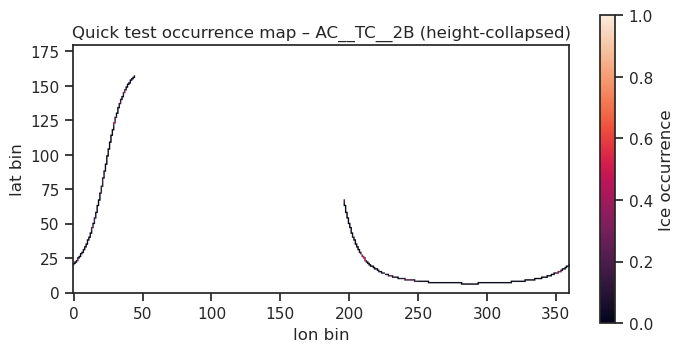

In [8]:
N_QUICK_TEST = min(5, len(zip_paths))

total_test = np.zeros_like(total_count_3d)
ice_test   = np.zeros_like(ice_count_3d)
failed_test      = []
processed_h5_test = 0

for src_zip in zip_paths[:N_QUICK_TEST]:
    local_zip = None
    extract_dir = None
    try:
        local_zip, extract_dir, h5_files = stage_zip_and_extract(src_zip, LOCAL_STAGE_ROOT)
        for fp in h5_files:
            t3d, i3d = accumulate_one_file(fp, lat_bins, lon_bins, target_h)
            total_test += t3d
            ice_test   += i3d
            processed_h5_test += 1
    except Exception as e:
        failed_test.append((str(src_zip), str(e)))
    finally:
        cleanup_staged_data(local_zip, extract_dir)

print(f"Tested ZIPs: {N_QUICK_TEST}  |  H5 processed: {processed_h5_test}  |  Failed: {len(failed_test)}")
print("Total valid pixels:", int(np.nansum(total_test)))
print("Total ice pixels:  ", int(np.nansum(ice_test)))
if np.nansum(total_test) > 0:
    print("Overall ice occurrence (test):", float(np.nansum(ice_test) / np.nansum(total_test)))

if failed_test:
    print("\nFirst failure:", failed_test[0][1])

# Quick look
num2d = np.nansum(ice_test,   axis=2)
den2d = np.nansum(total_test, axis=2)
occ2d = np.divide(num2d, den2d, out=np.full_like(num2d, np.nan), where=den2d > 0)

plt.figure(figsize=(8, 4))
plt.imshow(occ2d, origin="lower", vmin=0, vmax=1)
plt.colorbar(label="Ice occurrence")
plt.title("Quick test occurrence map – AC__TC__2B (height-collapsed)")
plt.xlabel("lon bin")
plt.ylabel("lat bin")
plt.show()

**7. Full Batch Processing**

In [9]:
# Re-initialise accumulators (safe to re-run cell)
total_count_3d = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)
ice_count_3d   = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)

failed_zips  = []
processed_h5 = 0
n_zips       = len(zip_paths)

for idx, src_zip in enumerate(zip_paths, start=1):
    local_zip = None
    extract_dir = None
    try:
        local_zip, extract_dir, h5_files = stage_zip_and_extract(src_zip, LOCAL_STAGE_ROOT)
        for fp in h5_files:
            t3d, i3d = accumulate_one_file(fp, lat_bins, lon_bins, target_h)
            total_count_3d += t3d
            ice_count_3d   += i3d
            processed_h5   += 1
    except Exception as e:
        failed_zips.append((str(src_zip), str(e)))
    finally:
        cleanup_staged_data(local_zip, extract_dir)

    if idx % 10 == 0 or idx == n_zips:
        print(f"{idx}/{n_zips} ZIPs | h5={processed_h5} | failed={len(failed_zips)}")

print("\nBatch done")
print(f"H5 files processed: {processed_h5}  |  ZIP failures: {len(failed_zips)}")
tot_sum = np.nansum(total_count_3d)
if tot_sum > 0:
    print(f"Total valid pixels:     {int(tot_sum)}")
    print(f"Overall ice occurrence: {float(np.nansum(ice_count_3d)/tot_sum):.4f}")

if failed_zips:
    print("\nFirst 3 failures:")
    for z, err in failed_zips[:3]:
        print(" -", z)
        print("   ", err)

10/42625 ZIPs | h5=10 | failed=0
20/42625 ZIPs | h5=20 | failed=0
30/42625 ZIPs | h5=30 | failed=0
40/42625 ZIPs | h5=40 | failed=0
50/42625 ZIPs | h5=50 | failed=0
60/42625 ZIPs | h5=60 | failed=0
70/42625 ZIPs | h5=70 | failed=0
80/42625 ZIPs | h5=80 | failed=0
90/42625 ZIPs | h5=90 | failed=0
100/42625 ZIPs | h5=100 | failed=0
110/42625 ZIPs | h5=110 | failed=0
120/42625 ZIPs | h5=120 | failed=0
130/42625 ZIPs | h5=130 | failed=0
140/42625 ZIPs | h5=140 | failed=0
150/42625 ZIPs | h5=150 | failed=0
160/42625 ZIPs | h5=160 | failed=0
170/42625 ZIPs | h5=170 | failed=0
180/42625 ZIPs | h5=180 | failed=0
190/42625 ZIPs | h5=190 | failed=0
200/42625 ZIPs | h5=200 | failed=0
210/42625 ZIPs | h5=210 | failed=0
220/42625 ZIPs | h5=220 | failed=0
230/42625 ZIPs | h5=230 | failed=0
240/42625 ZIPs | h5=240 | failed=0
250/42625 ZIPs | h5=250 | failed=0
260/42625 ZIPs | h5=260 | failed=0
270/42625 ZIPs | h5=270 | failed=0
280/42625 ZIPs | h5=280 | failed=0
290/42625 ZIPs | h5=290 | failed=0
300

**8. Occurrence Map**

In [10]:
# Height-collapsed 2D maps (lat, lon)
ice_2d = np.nansum(ice_count_3d,   axis=2)
tot_2d = np.nansum(total_count_3d, axis=2)

occurrence_2d = np.divide(
    ice_2d, tot_2d,
    out=np.full_like(ice_2d, np.nan, dtype=np.float64),
    where=tot_2d > 0,
)
if MIN_SAMPLES_PER_CELL and MIN_SAMPLES_PER_CELL > 0:
    occurrence_2d[tot_2d < MIN_SAMPLES_PER_CELL] = np.nan

# Lat/height map (longitude collapsed)
ice_lh = np.nansum(ice_count_3d,   axis=1)
tot_lh = np.nansum(total_count_3d, axis=1)

occurrence_lh = np.divide(
    ice_lh, tot_lh,
    out=np.full_like(ice_lh, np.nan, dtype=np.float64),
    where=tot_lh > 0,
)
if MIN_SAMPLES_PER_CELL and MIN_SAMPLES_PER_CELL > 0:
    occurrence_lh[tot_lh < MIN_SAMPLES_PER_CELL] = np.nan   # Fix: apply threshold

print("Occurrence computed")
print(f"2D (lat/lon):    {occurrence_2d.shape}")
print(f"2D (lat/height): {occurrence_lh.shape}")
tot_sum = np.nansum(total_count_3d)
if tot_sum > 0:
    print(f"Global ice occurrence: {float(np.nansum(ice_count_3d)/tot_sum):.6f}")

Occurrence computed
2D (lat/lon):    (180, 360)
2D (lat/height): (180, 201)
Global ice occurrence: 0.094988


**9. Save to NetCDF**

In [11]:
outdir = f"{OUTPUT_ROOT}/{start_dt:%Y%m%d}_{end_dt:%Y%m%d}"
os.makedirs(outdir, exist_ok=True)

_base = f"AC_TC_2B_{GRID_RES_DEG}deg_{start_dt:%Y%m%d}_{end_dt:%Y%m%d}"

# --- 3D occurrence (lat x lon x height) ---
occurrence_3d = np.divide(
    ice_count_3d, total_count_3d,
    out=np.full_like(ice_count_3d, np.nan, dtype=np.float64),
    where=total_count_3d > 0,
)
if MIN_SAMPLES_PER_CELL and MIN_SAMPLES_PER_CELL > 0:
    occurrence_3d[total_count_3d < MIN_SAMPLES_PER_CELL] = np.nan

xr.Dataset(
    {"occurrence":  (["latitude", "longitude", "height"], occurrence_3d),
     "ice_count":   (["latitude", "longitude", "height"], ice_count_3d),
     "total_count": (["latitude", "longitude", "height"], total_count_3d)},
    coords={"latitude": lat_centers, "longitude": lon_centers, "height": target_h},
).to_netcdf(f"{outdir}/{_base}_occurrence_3d.nc")

# --- Lat/lon occurrence map (height-collapsed) ---
xr.Dataset(
    {"occurrence":  (["latitude", "longitude"], occurrence_2d),
     "ice_count":   (["latitude", "longitude"], ice_2d),
     "total_count": (["latitude", "longitude"], tot_2d)},
    coords={"latitude": lat_centers, "longitude": lon_centers},
).to_netcdf(f"{outdir}/{_base}_occurrence_latlon.nc")

# --- Lat/height occurrence map (longitude-collapsed) ---
xr.Dataset(
    {"occurrence":  (["latitude", "height"], occurrence_lh),
     "ice_count":   (["latitude", "height"], ice_lh),
     "total_count": (["latitude", "height"], tot_lh)},
    coords={"latitude": lat_centers, "height": target_h},
).to_netcdf(f"{outdir}/{_base}_occurrence_latheight.nc")

print(f"Saved to {outdir}/")
print(f"  {_base}_occurrence_3d.nc          (lat x lon x height)")
print(f"  {_base}_occurrence_latlon.nc       (lat x lon, height-collapsed)")
print(f"  {_base}_occurrence_latheight.nc    (lat x height, zonal mean)")

Saved to /usr/people/raucher/Documents/Coding1/KNMI/KNMI/ACTC_output/20250101_20260228/
  AC_TC_2B_1.0deg_20250101_20260228_occurrence_3d.nc          (lat x lon x height)
  AC_TC_2B_1.0deg_20250101_20260228_occurrence_latlon.nc       (lat x lon, height-collapsed)
  AC_TC_2B_1.0deg_20250101_20260228_occurrence_latheight.nc    (lat x height, zonal mean)
